In [ ]:
import kagglehub, pandas as pd
from pathlib import Path

# 1) Grab (or reuse) the dataset
ds_path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")
print("Local folder:", ds_path)

# 2) Inspect file list (there are usually several CSVs)
csv_file = next(Path(ds_path).rglob("btcusd_1-min_data*.csv"))
print("Loaded file:", csv_file.name)

# 3) Pick the daily-price file  (often named 'bitcoin.csv' or similar)
df = pd.read_csv(csv_file)

Local folder: /kaggle/input/bitcoin-historical-data
Loaded file: btcusd_1-min_data.csv


In [ ]:
df["Date"] = pd.to_datetime(df["Timestamp"].astype("int64"), unit="s", utc=True)
df = df.set_index("Date").drop(columns=["Timestamp"])

In [ ]:
# original minute-level DataFrame → df  (index must be datetime)

hourly = (
    df.resample("1H")
      .agg({
          "Open":   "first",
          "High":   "max",
          "Low":    "min",
          "Close":  "last",
          "Volume": "sum"
      })
      .dropna()          # drops any incomplete hour at the end
)


/tmp/ipython-input-71-3060467380.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df.resample("1H")


In [ ]:
import numpy as np, pandas as pd

h = hourly.copy()
h = h.loc["2024-10-01":"2025-01-01"] .copy()
close, high, low = h["Close"], h["High"], h["Low"]

# MACD 12-26-9
ema12, ema26 = close.ewm(span=12).mean(), close.ewm(span=26).mean()
h["MACD"] = ema12 - ema26
h["MACD_Signal"] = h["MACD"].ewm(span=9).mean()

# RSI-14
delta = close.diff()
gain, loss = delta.clip(lower=0), -delta.clip(upper=0)
rs = gain.rolling(14).mean() / loss.rolling(14).mean()
h["RSI_14"] = 100 - 100 / (1 + rs)

# KDJ 9-3-3
low9, high9 = low.rolling(9).min(), high.rolling(9).max()
h["%K"] = 100 * (close - low9) / (high9 - low9)
h["%D"] = h["%K"].rolling(3).mean()
h["KDJ_J"] = 3 * h["%K"] - 2 * h["%D"]


In [ ]:
def rsi(series, length):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(length).mean()
    loss  = (-delta.clip(upper=0)).rolling(length).mean()
    rs = gain / loss
    return 100 - 100 / (1 + rs)

h["RSI_6"]  = rsi(h["Close"],  6)   # “fast”
h["RSI_14"] = rsi(h["Close"], 14)   # “standard”
h["RSI_24"] = rsi(h["Close"], 24)   # “slow”


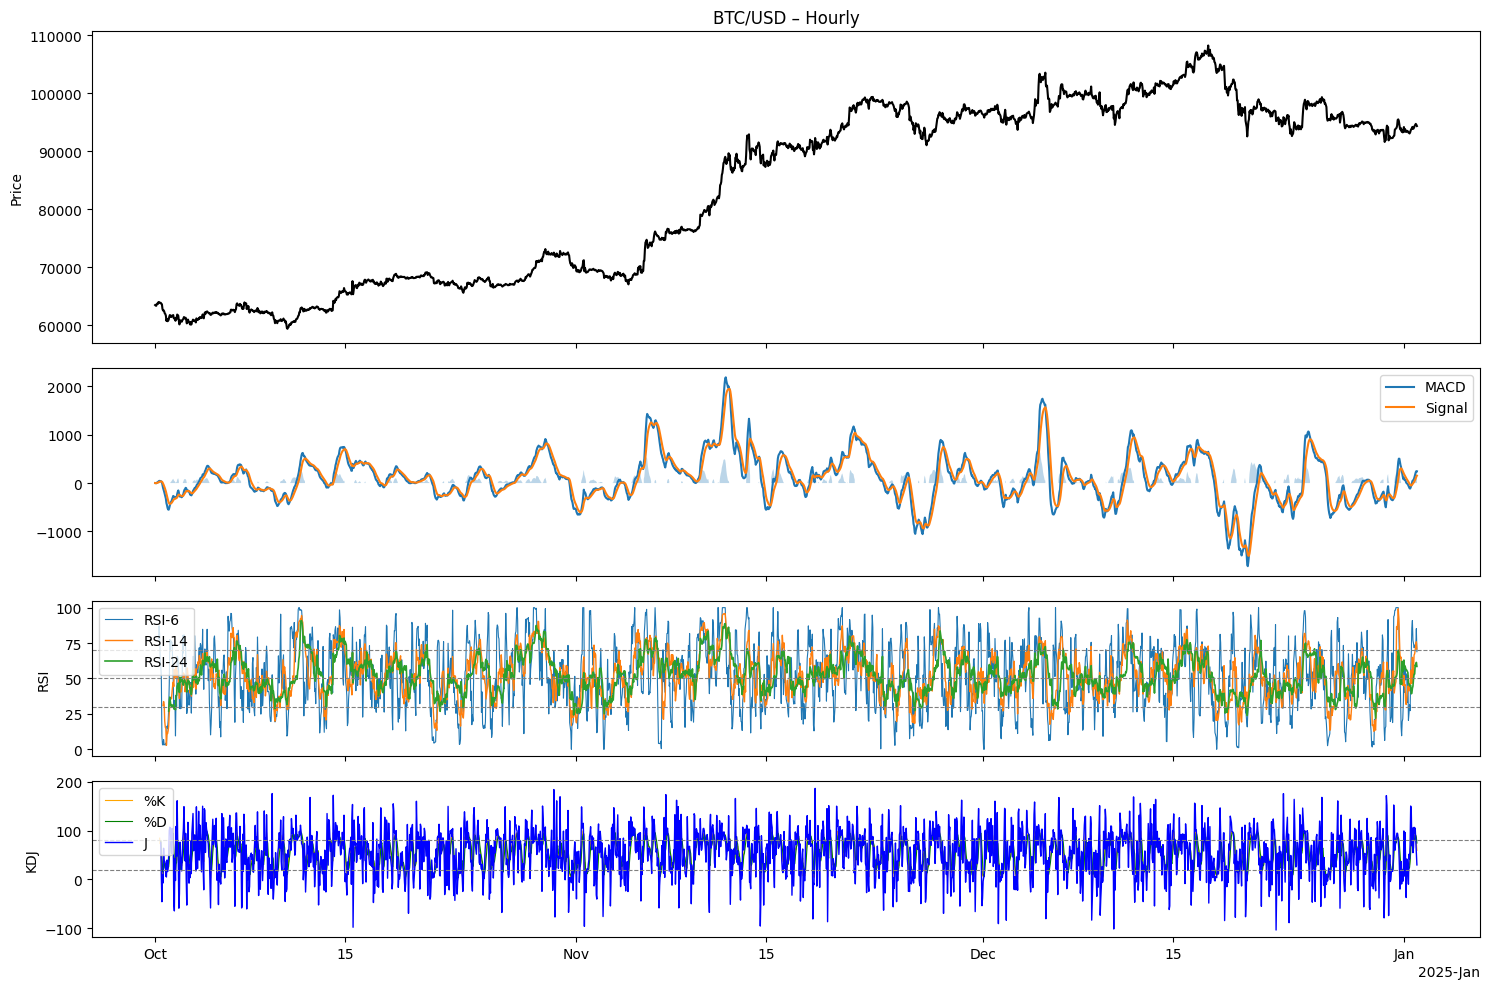

In [ ]:
import matplotlib.pyplot as plt, matplotlib.dates as mdates

fig, (ax_p, ax_macd, ax_rsi, ax_kdj) = plt.subplots(
    4, 1, figsize=(15, 10), sharex=True,
    gridspec_kw={"height_ratios": [3, 2, 1.5, 1.5]}
)

# price
ax_p.plot(h.index, h["Close"], color="black")
ax_p.set_title("BTC/USD – Hourly")
ax_p.set_ylabel("Price")

# MACD
ax_macd.plot(h.index, h["MACD"], label="MACD")
ax_macd.plot(h.index, h["MACD_Signal"], label="Signal")
ax_macd.fill_between(h.index, 0, h["MACD"] - h["MACD_Signal"],
                     where=(h["MACD"] - h["MACD_Signal"]) >= 0, alpha=.3)
ax_macd.legend()

# ── Triple-RSI
ax_rsi.plot(h.index, h["RSI_6"],  label="RSI-6",  lw=0.8)
ax_rsi.plot(h.index, h["RSI_14"], label="RSI-14", lw=1.0)
ax_rsi.plot(h.index, h["RSI_24"], label="RSI-24", lw=1.2)
for y in (70, 50, 30):
    ax_rsi.axhline(y, color="grey", ls="--", lw=0.8)
ax_rsi.set_ylabel("RSI")
ax_rsi.legend(loc="upper left")

# ── Triple-KDJ
ax_kdj.plot(h.index, h["%K"],    label="%K", color="orange", lw=0.8)
ax_kdj.plot(h.index, h["%D"],    label="%D", color="green",  lw=0.8)
ax_kdj.plot(h.index, h["KDJ_J"], label="J",  color="blue",   lw=1.0)
ax_kdj.axhline(80, color="grey", ls="--", lw=0.8)
ax_kdj.axhline(20, color="grey", ls="--", lw=0.8)
ax_kdj.set_ylabel("KDJ")
ax_kdj.legend(loc="upper left")


# x-axis formatter that works for any span
locator = mdates.AutoDateLocator(minticks=6, maxticks=12)
ax_kdj.xaxis.set_major_locator(locator)
ax_kdj.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd, numpy as np
from itertools import combinations

# ------------------------------------------------------------------
# 0.  Build *all* base indicator cues once
# ------------------------------------------------------------------
h3 = h.copy()


# 2) ensure its index is tz‑naive (so .loc[] on signals.index works)
if getattr(h3.index, "tz", None) is not None:
    h3.index = h3.index.tz_convert(None)

# ----  Long-term trend (EMA-200)  ----
h3["EMA200"]   = h3["Close"].ewm(span=200).mean()
h3["trend_up"] = h3["Close"] > h3["EMA200"]     # bullish regime
h3["trend_dn"] = ~h3["trend_up"]                # bearish / neutral

# ---- MACD slope curls ----
h3["macd_slope"] = h3["MACD"].diff()
h3["macd_up"] = (
    (h3["macd_slope"] > 0) & (h3["macd_slope"].shift(1) <= 0) &
    (h3["MACD"] < h3["MACD_Signal"])
)
h3["macd_dn"] = (
    (h3["macd_slope"] < 0) & (h3["macd_slope"].shift(1) >= 0) &
    (h3["MACD"] > h3["MACD_Signal"])
)
h3["hist_dn"] = (
    (h3["MACD"] < h3["MACD_Signal"]) &
    (h3["MACD"].shift(1) >= h3["MACD_Signal"].shift(1))
)   # optional backup exit

# ---- RSI fast / slow cross (6 vs 24) ----
h3["rsi_fast_above"] = (h3["RSI_6"] > h3["RSI_24"]).astype(int)
h3["rsi_up"] = h3["rsi_fast_above"].diff() ==  1
h3["rsi_dn"] = h3["rsi_fast_above"].diff() == -1

# ---- KDJ cross (%K vs %D) ----
h3["kdj_fast_above"] = (h3["%K"] > h3["%D"]).astype(int)
h3["kdj_up"] = h3["kdj_fast_above"].diff() ==  1
h3["kdj_dn"] = h3["kdj_fast_above"].diff() == -1

# # %K exits oversold  → BUY cue
# h3["kdj_up"] = (h3["%K"] > 20) & (h3["%K"].shift(1) <= 20)

# # %K exits overbought → SELL cue
# h3["kdj_dn"] = (h3["%K"] < 80) & (h3["%K"].shift(1) >= 80)

ma_len = 20
th_up  = 1.2        # 150 % of MA20
th_dn  = 0.7        # 70 % of MA20

h3["vol_ma20"] = h3["Volume"].rolling(ma_len).mean()
h3["vol_up"]   = h3["Volume"] >= th_up * h3["vol_ma20"]
h3["vol_dn"]   = h3["Volume"] <= th_dn * h3["vol_ma20"]
# drop initial NaNs once, or leave them — they evaluate to False

# ---- extend cue_map ----------------------------------------
cue_map = {
    "MACD"  : ("macd_up",   "macd_dn"),
    "RSI"   : ("rsi_up",    "rsi_dn"),
    "KDJ"   : ("kdj_up",    "kdj_dn"),
    "TREND" : ("trend_up",  "trend_dn"),
    "VOL"   : ("vol_up",    "vol_dn"),     # ← NEW
}


# ------------------------------------------------------------------
# 1.  Back-test helper  (still 1×, 0.015 % fee)
# ------------------------------------------------------------------
FEE = 0.00015                           # 0.015 %

def run_backtest(buy_cols, sell_cols):
    cash, btc, trades = 1000.0, 0.0, 0
    for ts, row in h3.iterrows():
        price = row["Close"]
        buy_sig  = all(row[c] for c in buy_cols)
        sell_sig = all(row[c] for c in sell_cols) or row["hist_dn"]

        if btc == 0 and buy_sig:                        # BUY all-in
            btc   = cash / price * (1 - FEE)
            cash  = 0.0
            trades += 1

        elif btc > 0 and sell_sig:                      # SELL all-out
            cash  = btc * price * (1 - FEE)
            btc   = 0.0
            trades += 1

    # liquidate at the end if still long
    if btc:
        cash  = btc * h3.iloc[-1]["Close"] * (1 - FEE)
        trades += 1

    return cash, trades

# ------------------------------------------------------------------
# 2.  Test every 1-, 2-, 3- and 4-indicator combination
# ------------------------------------------------------------------
results = []
for k in (1, 2, 3, 4, 5):
    for combo in combinations(cue_map.keys(), k):
        buys  = [cue_map[c][0] for c in combo]
        sells = [cue_map[c][1] for c in combo]
        equity, n_trades = run_backtest(buys, sells)
        results.append({"Combo":"+".join(combo),
                        "Equity":equity,
                        "Trades":n_trades})

summary = pd.DataFrame(results).sort_values("Equity", ascending=False)

# ------------------------------------------------------------------
# 3.  Benchmark & display
# ------------------------------------------------------------------
buy_hold = 1000.0 * h3.iloc[-1]["Close"] / h3.iloc[0]["Close"]
summary["Δ vs BuyHold"] = summary["Equity"] - buy_hold

print(f"Buy-and-hold equity: ${buy_hold:,.2f}\n")
print(summary.to_string(index=False,
                        formatters={"Equity":"${:,.2f}".format,
                                    "Δ vs BuyHold":"${:,.2f}".format}))

Buy-and-hold equity: $1,486.05

                 Combo    Equity  Trades Δ vs BuyHold
               KDJ+VOL $1,313.94     210     $-172.11
         KDJ+TREND+VOL $1,309.34     106     $-176.71
             TREND+VOL $1,291.37     138     $-194.68
                 TREND $1,216.22     200     $-269.83
                   VOL $1,190.88     486     $-295.17
             KDJ+TREND $1,171.62     156     $-314.43
             RSI+TREND $1,107.56     128     $-378.49
            MACD+TREND $1,093.23      86     $-392.82
        MACD+TREND+VOL $1,053.72      48     $-432.33
         RSI+TREND+VOL $1,050.99      84     $-435.06
              MACD+VOL $1,035.00      68     $-451.05
     RSI+KDJ+TREND+VOL $1,012.88      42     $-473.17
    MACD+RSI+KDJ+TREND $1,004.42      20     $-481.63
        MACD+RSI+TREND $1,003.35      48     $-482.70
        MACD+KDJ+TREND $1,000.75      46     $-485.30
           RSI+KDJ+VOL   $996.22      64     $-489.83
               RSI+KDJ   $991.82     158     $-494

In [ ]:
import numpy as np
import pandas as pd
from itertools import combinations, product

# ────────────────────────────────────────────────────────────────────────
# 0) CONFIG
# ────────────────────────────────────────────────────────────────────────
START_CASH = 1_000.0
FEE        = 0.00015       # 0.015 %

# map each cue to its buy and sell column names
# e.g. cue_map = {"macd": ("macd_long", "macd_short"), ...}
# make sure h3 is already defined and contains those columns
# ────────────────────────────────────────────────────────────────────────

def run_backtest(buy_cols, sell_cols, TP_PCT, TRAIL_PCT):
    cash, btc, trades = START_CASH, 0.0, 0
    entry_price = peak_price = None
    # precompute ATR14 if not present
    if "ATR14" not in h3:
        h3["ATR14"] = (h3["High"] - h3["Low"]).rolling(14).mean()

    for _, row in h3.iterrows():
        price    = row["Close"]
        buy_sig  = all(row[c] for c in buy_cols)
        sell_sig = all(row[c] for c in sell_cols) or row.get("hist_dn", False)

        # ── ENTRY ───────────────────────────────────────
        if btc == 0 and buy_sig:
            btc         = cash / price * (1 - FEE)
            cash        = 0.0
            entry_price = peak_price = price
            trades     += 1
            continue

        # ── IN‑TRADE ───────────────────────────────────
        if btc > 0:
            peak_price = max(peak_price, price)

            # take‑profit
            if price >= entry_price * (1 + TP_PCT):
                cash = btc * price * (1 - FEE)
                btc  = 0.0
                trades += 1
                continue

            # trailing‑stop
            if price <= peak_price * (1 - TRAIL_PCT):
                cash = btc * price * (1 - FEE)
                btc  = 0.0
                trades += 1
                continue

            # normal indicator exit
            if sell_sig:
                cash = btc * price * (1 - FEE)
                btc  = 0.0
                trades += 1

    # ── FINAL LIQUIDATION ─────────────────────────────
    if btc:
        cash = btc * h3.iloc[-1]["Close"] * (1 - FEE)
        trades += 1

    return cash, trades

# ────────────────────────────────────────────────────────────────────────
# 1) GRID‑SEARCH: combos × TP_PCT × TRAIL_PCT
# ────────────────────────────────────────────────────────────────────────
results = []
all_cues = list(cue_map.keys())

# ranges to sweep (tweak resolution as you like)
tp_range    = np.arange(0.02, 0.11, 0.01)   # 2 % → 10 % by 1 %
trail_range = np.arange(0.01, 0.06, 0.01)   # 1 % → 5 % by 1 %

for k in range(1, len(all_cues) + 1):
    for combo in combinations(all_cues, k):
        buys  = [cue_map[c][0] for c in combo]
        sells = [cue_map[c][1] for c in combo]
        for TP_PCT, TRAIL_PCT in product(tp_range, trail_range):
            equity, n_trades = run_backtest(buys, sells, TP_PCT, TRAIL_PCT)
            results.append({
                "Combo":       "+".join(combo),
                "TP_PCT":      TP_PCT,
                "TRAIL_PCT":   TRAIL_PCT,
                "Equity":      equity,
                "Trades":      n_trades
            })

summary = pd.DataFrame(results)
summary["Δ vs BH"] = summary["Equity"] - (START_CASH * h3.iloc[-1]["Close"] / h3.iloc[0]["Close"])
best = summary.sort_values("Equity", ascending=False).iloc[0]

print("🏆 BEST SETTINGS:")
print(f"Indicators : {best.Combo}")
print(f"Take‑profit: {best.TP_PCT:.3%}")
print(f"Trail-stop : {best.TRAIL_PCT:.3%}")
print(f"Equity      : ${best.Equity:,.2f}")
print(f"Trades      : {best.Trades}")
print(f"Δ vs BH     : ${best['Δ vs BH']:,.2f}")

# ────────────────────────────────────────────────────────────────────────
# 2) OPTIONAL: inspect top‑5 combinations
# ────────────────────────────────────────────────────────────────────────
print("\nTop 5:")
print(summary.sort_values("Equity", ascending=False).head(5).to_string(
    index=False,
    formatters={
        "TP_PCT":    "{:.1%}".format,
        "TRAIL_PCT": "{:.1%}".format,
        "Equity":    "${:,.2f}".format,
        "Δ vs BH":   "${:,.2f}".format
    }
))


🏆 BEST SETTINGS:
Indicators : KDJ+TREND+VOL
Take‑profit: 2.000%
Trail-stop : 4.000%
Equity      : $1,457.83
Trades      : 120
Δ vs BH     : $-28.22

Top 5:
        Combo TP_PCT TRAIL_PCT    Equity  Trades  Δ vs BH
KDJ+TREND+VOL   2.0%      4.0% $1,457.83     120  $-28.22
KDJ+TREND+VOL   2.0%      5.0% $1,447.18     120  $-38.87
KDJ+TREND+VOL   2.0%      3.0% $1,442.05     122  $-44.00
KDJ+TREND+VOL   6.0%      4.0% $1,392.29     106  $-93.76
KDJ+TREND+VOL   6.0%      5.0% $1,382.12     106 $-103.93


In [ ]:
!pip install pytorch_forecasting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.9/260.9 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.1/821.1 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 105.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd
import numpy as np
import pytorch_forecasting as pf
from pytorch_forecasting import TimeSeriesDataSet

# ────────────────────────────────────────────────────────────────
# A) CONFIGURE your windows here
# ────────────────────────────────────────────────────────────────
TRAIN_START = "2023-04-01"
TRAIN_END   = "2025-04-01 23:59"
TEST_START  = "2024-10-01 00:00"
TEST_END    = None   # None → through the end of your data

In [ ]:
hourly[["Open","High","Low","Close"]] = hourly[["Open","High","Low","Close"]].ffill()
hourly["Volume"] = hourly["Volume"].fillna(0)

# reset index → Date column
hourly = hourly.reset_index().rename(columns={"index":"Date"})

# static
hourly["symbol"] = "BTC"

# placeholder exogenous series (needed by your dataset)
hourly["imbalance"]   = 0.0
hourly["funding_pct"] = 0.0
hourly["inflow"]      = 0.0

# time idx
hourly["time_idx"] = np.arange(len(hourly))

# cyclical time features
hourly["hour"]     = hourly["Date"].dt.hour
hourly["hour_sin"] = np.sin(2*np.pi*hourly["hour"]/24)
hourly["hour_cos"] = np.cos(2*np.pi*hourly["hour"]/24)

hourly["week"]     = hourly["Date"].dt.isocalendar().week.astype(int)
hourly["week_sin"] = np.sin(2*np.pi*hourly["week"]/52)
hourly["week_cos"] = np.cos(2*np.pi*hourly["week"]/52)

# technicals
def ema(s, span): return s.ewm(span=span, adjust=False).mean()
macd_line = ema(hourly["Close"], 12) - ema(hourly["Close"], 26)
hourly["macd_hist"] = macd_line - ema(macd_line, 9)

tr = pd.concat([
    hourly["High"] - hourly["Low"],
    (hourly["High"] - hourly["Close"].shift()).abs(),
    (hourly["Low"]  - hourly["Close"].shift()).abs()
], axis=1).max(axis=1)
hourly["atr14"] = tr.rolling(14).mean()

delta = hourly["Close"].diff()
gain  = delta.clip(lower=0)
loss  = -delta.clip(upper=0)
rs    = gain.rolling(14).mean() / loss.rolling(14).mean()
hourly["rsi14"] = 100 - 100 / (1 + rs)

# target
hourly["pct_fwd_4h"] = hourly["Close"].pct_change(-4)
hourly = hourly.dropna().reset_index(drop=True)

# ────────────────────────────────────────────────────────────────
# D) SLICE FOR TRAINING and BUILD dataset
# ────────────────────────────────────────────────────────────────
mask_tr = (hourly["Date"]>=TRAIN_START)&(hourly["Date"]<=TRAIN_END)
hourly_train = hourly.loc[mask_tr].copy()
dataset = TimeSeriesDataSet(
    hourly_train,
    time_idx="time_idx", target="pct_fwd_4h",
    group_ids=["symbol"],
    max_encoder_length=168,
    max_prediction_length=4,
    static_categoricals=["symbol"],
    time_varying_known_reals=["hour_sin","hour_cos","week_sin","week_cos"],
    time_varying_unknown_reals=[
        "Close","Volume","imbalance","funding_pct","inflow",
        "macd_hist","atr14","rsi14"
    ],
    target_normalizer=pf.GroupNormalizer(groups=["symbol"], transformation="softplus"),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True
)
print("TRAIN dataset ready →", dataset)

# ────────────────────────────────────────────────────────────────
# E) BUILD INFERENCE SET for TEST_WINDOW
# ────────────────────────────────────────────────────────────────
if TEST_END is None:
    TEST_END = hourly["Date"].max()

hist_len = dataset.max_encoder_length
hist_df  = hourly.loc[hourly["Date"]<TEST_START].tail(hist_len).copy()
future_df= hourly.loc[(hourly["Date"]>=TEST_START)&(hourly["Date"]<=TEST_END)].copy()

hist_df["pct_fwd_4h"]   = hist_df["pct_fwd_4h"].fillna(0.0)
future_df["pct_fwd_4h"] = 0.0

pred_df = pd.concat([hist_df, future_df], ignore_index=True)
pred_ds = TimeSeriesDataSet.from_dataset(dataset, pred_df, stop_randomization=True)
pred_loader = pred_ds.to_dataloader(train=False, batch_size=256)

print(f"INFERENCE set: history={len(hist_df)}, future={len(future_df)}")

TRAIN dataset ready → TimeSeriesDataSet[length=17379](
	time_idx='time_idx',
	target='pct_fwd_4h',
	group_ids=['symbol'],
	weight=None,
	max_encoder_length=168,
	min_encoder_length=168,
	min_prediction_idx=98582,
	min_prediction_length=4,
	max_prediction_length=4,
	static_categoricals=['symbol'],
	static_reals=None,
	time_varying_known_categoricals=None,
	time_varying_known_reals=['hour_sin', 'hour_cos', 'week_sin', 'week_cos'],
	time_varying_unknown_categoricals=None,
	time_varying_unknown_reals=['Close', 'Volume', 'imbalance', 'funding_pct', 'inflow', 'macd_hist', 'atr14', 'rsi14'],
	variable_groups=None,
	constant_fill_strategy=None,
	allow_missing_timesteps=True,
	lags=None,
	add_relative_time_idx=True,
	add_target_scales=True,
	add_encoder_length=True,
	target_normalizer=GroupNormalizer(
	method='standard',
	groups=['symbol'],
	center=True,
	scale_by_group=False,
	transformation='softplus',
	method_kwargs={}
),
	categorical_encoders={'__group_id__symbol': NaNLabelEncoder(add_nan=F

In [ ]:
import lightning.pytorch as pl          # NEW import path
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_forecasting.models import TemporalFusionTransformer


tft = TemporalFusionTransformer.from_dataset(
    dataset,
    hidden_size              = 64,
    lstm_layers              = 2,
    dropout                  = 0.10,
    attention_head_size      = 4,
    learning_rate            = 5e-4,
    loss                     = QuantileLoss(),
    log_interval             = 100,
    mask_bias=-float("inf"),
)

trainer = Trainer(
    accelerator = "gpu",
    devices     = 1,
    precision   = "16-mixed",          # new preferred flag
    max_epochs  = 30,
    callbacks   = [
        EarlyStopping(monitor="val_loss", patience=6, mode="min"),
        LearningRateMonitor("epoch")
    ],
    log_every_n_steps = 100,
)

train_loader = dataset.to_dataloader(train=True,  batch_size=128)
val_loader   = dataset.to_dataloader(train=False, batch_size=128)

trainer.fit(
    tft,
    train_dataloaders = train_loader,   # ← named arg
    val_dataloaders   = val_loader      # ← named arg
)


/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [lit

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


In [ ]:
pred_df = pd.concat([hist_df, future_df], ignore_index=True)
# time_idx was already continuous in `hourly`, so we leave it untouched

# ------------------------------------------------------------------
# 4) Build an inference dataset that re‑uses *all* encoders/scalers
# ------------------------------------------------------------------
pred_ds = TimeSeriesDataSet.from_dataset(
    dataset, pred_df, stop_randomization=True
)
pred_loader = pred_ds.to_dataloader(train=False, batch_size=256)

# ---------------------------------------------------------------
# 1) run the model – ask for index so alignment is trivial
# ---------------------------------------------------------------
out = tft.predict(
    pred_loader,
    mode="prediction",          # median forecast
    return_index=True,          # add row index as 2nd element
    return_decoder_lengths=False
)

# If you only want rows on/after the cutoff:
# keep_mask = pred_df.loc[row_idx, "Date"] >= pd.Timestamp("2025‑01‑02", tz="UTC")
# y_hat  = y_hat[keep_mask]
# row_idx = row_idx[keep_mask]
def get_position_and_dates(row_idx, pred_df):
    """
    Returns:
        pos   – integer positions in `pred_df`
        dates – pd.DatetimeIndex for those rows
    """
    import pandas as pd, numpy as np

    if isinstance(row_idx, pd.MultiIndex):
        # last level is always the integer time_idx
        pos = row_idx.get_level_values(-1).to_numpy()
    elif isinstance(row_idx, pd.DataFrame):
        # take the *last* numeric column, whatever it's called
        num_cols = [c for c in row_idx.columns if np.issubdtype(row_idx[c].dtype, np.integer)]
        if not num_cols:
            raise ValueError("No integer column to use as position index")
        pos = row_idx[num_cols[-1]].to_numpy()
    else:  # ndarray / list
        pos = np.asarray(row_idx)

    dates = pred_df.loc[pos, "Date"].to_numpy()
    return pos, dates


# ---------------------------------------------------------------
# 2) map forecast → probability
# ---------------------------------------------------------------
y_hat = tft.predict(pred_loader, mode="prediction").squeeze(-1).cpu().numpy()
y_hat = y_hat[:, 0]                              # horizon‑0 → 1‑D


row_idx   = pred_ds.index                       # DataFrame you printed
ENC_LEN = dataset.max_encoder_length          # 168
pos = row_idx["index_start"].to_numpy() + ENC_LEN
dates     = pred_df.loc[pos, "Date"].values
price_now = pred_df.loc[pos, "Close"].values

# ---------------------------------------------------------------
# 2) probability mapping
# ---------------------------------------------------------------
expected_ret = y_hat                            # already pct return
p_up = 1 / (1 + np.exp(-SIGMOID_K * expected_ret))
sig = pd.Series(p_up, index=pd.DatetimeIndex(dates, tz="UTC"))
sig.index = sig.index.tz_convert(None)      #  <-- add this line

# ---------------------------------------------------------------
# 4) trading loop is identical to your GRU example
# ---------------------------------------------------------------
price_lookup = hourly.set_index("Date")["Close"]    # ← align index once

cash, asset, equity = START_CASH, 0.0, []
for ts, p in sig.items():
    price = price_lookup.at[ts]                     # timestamp lookup OK

    if asset == 0 and p > THRESH_LONG:              # entry
        asset = cash / price * (1 - FEE)
        cash  = 0.0

    elif asset > 0 and p < THRESH_FLAT:             # exit
        cash  = asset * price * (1 - FEE)
        asset = 0.0

    equity.append(cash + asset * price)

# final liquidation
if asset:
    cash = asset * price_lookup.at[sig.index[-1]] * (1 - FEE)

final_equity = equity[-1]
buy_hold = (START_CASH *
            price_lookup.at[sig.index[-1]] / price_lookup.at[sig.index[0]])
print(sig.index[-1], sig.index[0])
print(f"TFT strategy equity:   ${final_equity:,.2f}")
print(f"Buy‑and‑hold equity:   ${buy_hold:,.2f}")

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 💡 Tip: For seamless cloud

2025-07-19 17:00:00 2024-10-01 00:00:00
TFT strategy equity:   $1,844.22
Buy‑and‑hold equity:   $1,855.74


In [ ]:

h3 = h.loc["2024-10-01":"2025-01-01"].copy()
h3["EMA200"]   = h3["Close"].ewm(span=200).mean()
h3["trend_up"] = h3["Close"] > h3["EMA200"]     # bullish regime
h3["trend_dn"] = ~h3["trend_up"]                # bearish / neutral

# ---- MACD slope curls ----
h3["macd_slope"] = h3["MACD"].diff()
h3["macd_up"] = (
    (h3["macd_slope"] > 0) & (h3["macd_slope"].shift(1) <= 0) &
    (h3["MACD"] < h3["MACD_Signal"])
)
h3["macd_dn"] = (
    (h3["macd_slope"] < 0) & (h3["macd_slope"].shift(1) >= 0) &
    (h3["MACD"] > h3["MACD_Signal"])
)
h3["hist_dn"] = (
    (h3["MACD"] < h3["MACD_Signal"]) &
    (h3["MACD"].shift(1) >= h3["MACD_Signal"].shift(1))
)   # optional backup exit

# ---- RSI fast / slow cross (6 vs 24) ----
h3["rsi_fast_above"] = (h3["RSI_6"] > h3["RSI_24"]).astype(int)
h3["rsi_up"] = h3["rsi_fast_above"].diff() ==  1
h3["rsi_dn"] = h3["rsi_fast_above"].diff() == -1

# ---- KDJ cross (%K vs %D) ----
h3["kdj_fast_above"] = (h3["%K"] > h3["%D"]).astype(int)
h3["kdj_up"] = h3["kdj_fast_above"].diff() ==  1
h3["kdj_dn"] = h3["kdj_fast_above"].diff() == -1

# ---- Map indicator names → (buy cue, sell cue) ----
cue_map = {
    "MACD"  : ("macd_up",   "macd_dn"),
    "RSI"   : ("rsi_up",    "rsi_dn"),
    "KDJ"   : ("kdj_up",    "kdj_dn"),
    "TREND" : ("trend_up",  "trend_dn"),
}


# ------------------------------------------------------------------
# 1.  Back-test helper  (still 1×, 0.015 % fee)
# ------------------------------------------------------------------
FEE       = 0.00015    # 0.015 %
TP_PCT    = 0.04       # 6.0 % take-profit
TRAIL_PCT = 0.01       # 2.0 % trailing stop

def run_backtest(buy_cols, sell_cols):
    cash, btc, trades = 1000.0, 0.0, 0
    entry_price  = None
    peak_price   = None
    h3["ATR14"] = (h3["High"] - h3["Low"]).rolling(14).mean()

    for _, row in h3.iterrows():
        price    = row["Close"]
        buy_sig  = all(row[c] for c in buy_cols)
        sell_sig = all(row[c] for c in sell_cols) or row["hist_dn"]

        # ── BUY ───────────────────────────────────────────────
        if btc == 0 and buy_sig:
            btc         = cash / price * (1 - FEE)
            cash        = 0.0
            entry_price = peak_price = price   # initialise both
            trades     += 1
            continue                            # jump to next bar

        # ── Already in a trade ────────────────────────────────
        if btc > 0:

            # update peak
            peak_price = max(peak_price, price)

            # # take-profit hits first
            # if price >= entry_price * (1 + TP_PCT):
            #     cash = btc * price * (1 - FEE); btc = 0; trades += 1
            #     continue
            # if btc and price >= entry_price + 7.5 * row["ATR14"] :
            #     cash = btc * price * (1 - FEE); btc = 0; trades += 1
            #     continue

            # # trailing stop
            # if price <= peak_price * (1 - TRAIL_PCT):
            #     cash = btc * price * (1 - FEE); btc = 0; trades += 1
            #     continue

            # normal indicator exit
            if sell_sig:
                cash = btc * price * (1 - FEE); btc = 0; trades += 1

    # ── final liquidation ────────────────────────────────────
    if btc:
        cash = btc * h3.iloc[-1]["Close"] * (1 - FEE)
        trades += 1

    return cash, trades


# ------------------------------------------------------------------
# 2.  Test every 1-, 2-, 3- and 4-indicator combination
# ------------------------------------------------------------------
results = []
for k in (1, 2, 3, 4):
    for combo in combinations(cue_map.keys(), k):
        buys  = [cue_map[c][0] for c in combo]
        sells = [cue_map[c][1] for c in combo]
        equity, n_trades = run_backtest(buys, sells)
        results.append({"Combo":"+".join(combo),
                        "Equity":equity,
                        "Trades":n_trades})

summary = pd.DataFrame(results).sort_values("Equity", ascending=False)

# ------------------------------------------------------------------
# 3.  Benchmark & display
# ------------------------------------------------------------------
buy_hold = 1000.0 * h3.iloc[-1]["Close"] / h3.iloc[0]["Close"]
summary["Δ vs BuyHold"] = summary["Equity"] - buy_hold

print(f"Buy-and-hold equity: ${buy_hold:,.2f}\n")
print(summary.to_string(index=False,
                        formatters={"Equity":"${:,.2f}".format,
                                    "Δ vs BuyHold":"${:,.2f}".format}))

NameError: name 'combinations' is not defined

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
START_CASH  = 1_000.0
FEE         = 0.00015          # taker fee per side
# trade_mode  = "long"           # "long" = buy lows, sell highs
trade_mode = "short"         # ↰ uncomment for short strategy

# ------------------------------------------------------------
# 1)  Identify strict local minima & maxima in 'Close'
# ------------------------------------------------------------
h2 = hourly.copy()
h = h2.loc["2025-04-01":] .copy()
price = h["Close"]

prev  = price.shift(1)
next_ = price.shift(-1)

min_idx = price[(price < prev) & (price < next_)].index
max_idx = price[(price > prev) & (price > next_)].index

# combine and sort chronologically
turns = pd.Index(min_idx.union(max_idx)).sort_values()

# ensure first turn matches strategy
if trade_mode == "long"  and turns[0] not in min_idx:
    turns = turns[1:]
elif trade_mode == "short" and turns[0] not in max_idx:
    turns = turns[1:]

# ------------------------------------------------------------
# 2)  Walk through turning points and execute trades
# ------------------------------------------------------------
cash, btc = START_CASH, 0.0
equity_curve = []                    # (timestamp, equity_usd)
n_trades = 0                         # ← track how many times we trade

for i in range(len(turns) - 1):
    entry_ts = turns[i]
    exit_ts  = turns[i + 1]

    entry_price = price.loc[entry_ts]
    exit_price  = price.loc[exit_ts]

    # LONG cycle: buy at valley → sell at peak
    if trade_mode == "long" and entry_ts in min_idx and exit_ts in max_idx:
        btc   = cash / entry_price * (1 - FEE)
        cash  = btc * exit_price * (1 - FEE)
        btc   = 0.0
        n_trades += 1

    # SHORT cycle: sell at peak → buy back at valley
    elif trade_mode == "short" and entry_ts in max_idx and exit_ts in min_idx:
        btc   = - cash / entry_price * (1 - FEE)
        cash += -btc * entry_price * (1 - FEE)
        cash += btc * exit_price * (1 - FEE)
        btc   = 0.0
        n_trades += 1

    equity_curve.append((exit_ts, cash))

# Liquidate any remaining position
if btc:
    cash = btc * price.iloc[-1] * (1 - FEE)
    equity_curve.append((price.index[-1], cash))

# Construct equity series
equity = pd.Series(
    [eq for _, eq in equity_curve],
    index=[ts for ts, _ in equity_curve]
)

# ------------------------------------------------------------
# 3)  Compute buy & hold and print summary
# ------------------------------------------------------------
buy_hold = START_CASH * price.iloc[-1] / price.iloc[0]

print(f"Final equity using '{trade_mode}' swing strategy: ${cash:,.2f}")
print(f"Buy‑and‑hold equity: ${buy_hold:,.2f}")
print(f"Total number of executed trades: {n_trades}")



Final equity using 'short' swing strategy: $55,236,857,442,174,379,109,412,196,831,813,635,832,361,986,962,454,819,321,495,675,384,732,563,715,969,871,622,897,148,100,608.00
Buy‑and‑hold equity: $256,076.35
Total number of executed trades: 26228


In [ ]:
ckpt_path = "TFT_2.ckpt"
from pytorch_forecasting import TemporalFusionTransformer

tft = TemporalFusionTransformer.load_from_checkpoint(
    ckpt_path,
    map_location="cuda",     # or "cpu"
    # you can override hyperparams if needed:
    # mask_bias=-float("inf"),
    # learning_rate=5e-4,
    # dataset=dataset,         # attach current dataset object (recommended)
)
tft.eval()


/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


TemporalFusionTransformer(
  	"attention_head_size":               4
  	"categorical_groups":                {}
  	"causal_attention":                  True
  	"dataset_parameters":                {'time_idx': 'time_idx', 'target': 'pct_fwd_4h', 'group_ids': ['symbol'], 'weight': None, 'max_encoder_length': 168, 'min_encoder_length': 168, 'min_prediction_idx': 96422, 'min_prediction_length': 4, 'max_prediction_length': 4, 'static_categoricals': ['symbol'], 'static_reals': None, 'time_varying_known_categoricals': None, 'time_varying_known_reals': ['hour_sin', 'hour_cos', 'week_sin', 'week_cos'], 'time_varying_unknown_categoricals': None, 'time_varying_unknown_reals': ['Close', 'Volume', 'imbalance', 'funding_pct', 'inflow', 'macd_hist', 'atr14', 'rsi14'], 'variable_groups': None, 'constant_fill_strategy': None, 'allow_missing_timesteps': True, 'lags': None, 'add_relative_time_idx': True, 'add_target_scales': True, 'add_encoder_length': True, 'target_normalizer': GroupNormalizer(
  		met

In [ ]:

out = tft.predict(
    pred_loader,
    mode="prediction",
    return_index=True,
    return_decoder_lengths=False
)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────────
# (Assume pred_df, pred_ds, pred_loader, tft, dataset are already defined)
# ─────────────────────────────────────────────────────────────────

# 1) run the model
hourly["Date"] = pd.to_datetime(hourly["Date"], utc=True)

# compute “now” in the same timezone
now = pd.Timestamp.now(tz="UTC")

# keep only rows from 2024‑04‑01 up through now
mask = (hourly["Date"] >= "2024-10-01") & (hourly["Date"] <= "2025-01-01")
hourly = hourly.loc[mask].reset_index(drop=True)
# set Date as the index (and sort it)
hourly = hourly.set_index("Date").sort_index()

# now slice directly
hourly = hourly.loc["2024-10-01":"2025-01-01"]

# if you need the Date back as a column
hourly = hourly.reset_index()


preds = out[0]                       # Tensor shape (N, 4, 1)
y_hat = preds.squeeze(-1).cpu().numpy()[:, 0]  # next‑hour returns → (N,)

# 3) get the row index from the dataset
row_idx = pred_ds.index              # DataFrame with index_start, time, etc.

# 4) compute your positions exactly as before
ENC_LEN = dataset.max_encoder_length  # 168
pos     = row_idx["index_start"].to_numpy() + ENC_LEN
dates   = pred_df.loc[pos, "Date"].values
price_now = pred_df.loc[pos, "Close"].values

# 3) build signal table & filter to 4h grid
p_up = 1 / (1 + np.exp(-SIGMOID_K * y_hat))
# signals over the full range, indexed by the true timestamps
signal_index = pd.DatetimeIndex(dates)

signals = pd.DataFrame(
    {"p_up": p_up, "ret": y_hat},
    index=signal_index
)

# then filter to the 4 h grid
signals = signals[signals.index.hour % 4 == 0]


# 4) set dynamic entry/exit thresholds
TH_LONG  = signals["p_up"].quantile(0.80)   # top 20 % → go long
TH_SHORT = signals["p_up"].quantile(0.20)   # bottom 20 % → go short
TH_EXIT  = 0.50                             # back to neutral

print(f"using TH_LONG={TH_LONG:.3f}, TH_SHORT={TH_SHORT:.3f}")

# 5) trading loop: long ↔ short ↔ flat
cash, asset, equity = START_CASH, 0.0, []
position = 0  # +1=long, -1=short, 0=flat
# 1) Drop the timezone from price_lookup (it’s tz‑aware right now)
if price_lookup.index.tz is not None:
    price_lookup.index = price_lookup.index.tz_convert(None)

# 2) Ensure signals.index is also naive (in case it's tz‑aware)
if getattr(signals.index, "tz", None) is not None:
    signals.index    = signals.index.tz_convert(None)

# 3) Now drop any signals before your April 1 start
cut = pd.Timestamp("2025-01-01")      # no tz on purpose
signals = signals.loc[cut:]
equity_curve = []
import pandas as pd
import matplotlib.pyplot as plt

# 5) trading loop: long ↔ short ↔ flat, track equity at each signal time
cash, asset = START_CASH, 0.0
position     = 0                    # +1=long, -1=short, 0=flat
equity_curve = []                   # list of (timestamp, equity_value)

for ts, row in signals.iterrows():
    p     = row["p_up"]
    price = price_lookup.at[ts]

    # EXIT rules
    if position ==  1 and p < TH_EXIT:   # exit long
        cash     = asset * price * (1 - FEE)
        asset    = 0.0
        position = 0
    elif position == -1 and p > TH_EXIT: # exit short
        cash    += asset * price * (1 - FEE)  # asset is negative
        asset    = 0.0
        position = 0

    # ENTRY rules (only if flat)
    if position == 0:
        if p > TH_LONG:                 # open long
            asset    =  cash / price * (1 - FEE)
            cash     = 0.0
            position = 1
        elif p < TH_SHORT:              # open short
            asset    = -cash / price * (1 - FEE)
            cash    += -asset * price * (1 - FEE)
            position = -1

    # record equity at this timestamp
    equity_value = cash + asset * price
    equity_curve.append((ts, equity_value))

# final liquidation if still open at the end
last_ts    = signals.index[-1]
last_price = price_lookup.iloc[-1]
if position != 0:
    if position == 1:
        cash = asset * last_price * (1 - FEE)
    else:
        cash += asset * last_price * (1 - FEE)
    equity_curve.append((last_ts, cash))

# build a time‑indexed Series from equity_curve
eq_series = pd.Series(
    [val for _, val in equity_curve],
    index=[ts  for ts, _ in equity_curve]
).sort_index()

# compute final and buy‑&‑hold equity
final_equity     = eq_series.iloc[-1]
first_ts    = signals.index[0]
last_ts     = signals.index[-1]

# compute buy & hold from first_ts → last_ts
buy_hold_equity = START_CASH * price_lookup.at[last_ts] / price_lookup.at[first_ts]

print(f"Buy&Hold equity:       ${buy_hold_equity:,.2f}")

print(f"Final TFT strat equity: ${final_equity:,.2f}")
print(f"Buy&Hold equity:       ${buy_hold_equity:,.2f}")

# plot the result
plt.figure(figsize=(10,5))
eq_series.plot(label="TFT 4h strategy")
plt.axhline(buy_hold_equity, ls="--", color="gray", label="Buy & hold")
plt.title("Equity Curve – TFT 4 h Extreme‑Signal Strategy")
plt.ylabel("Portfolio Value (USD)")
plt.legend()
plt.tight_layout()
plt.show()




ValueError: Length of values (6992) does not match length of index (6984)

🔍 Best thresholds → TH_LONG=0.900, TH_SHORT=0.600; Final equity=$1,640.99


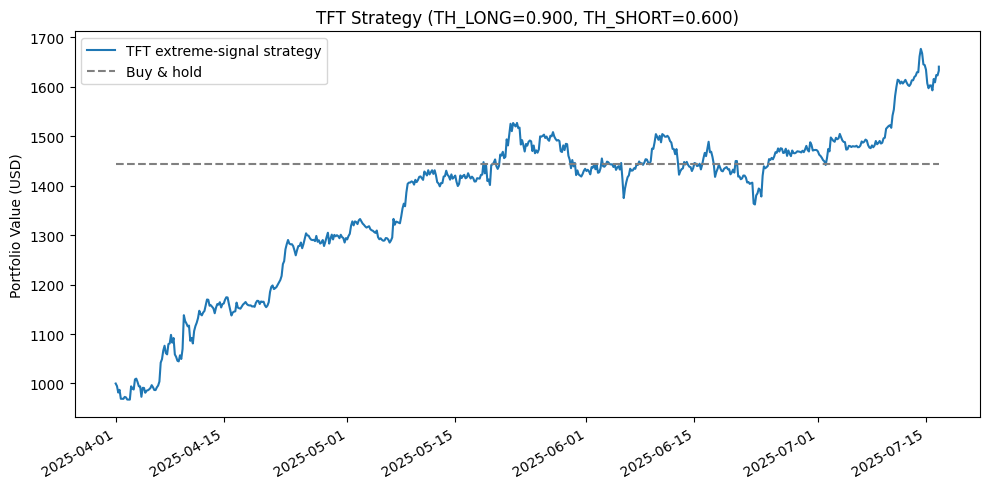

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

# ─────────────────────────────────────────────────────────────────
# 0) CONFIG
# ─────────────────────────────────────────────────────────────────
START_CASH = 1_000.0
FEE        = 0.00015        # 0.015 %
TH_EXIT    = 0.50           # exit to neutral

# assume you already have:
#   signals      – DataFrame indexed by timestamps, with columns ['p_up','ret']
#   price_lookup – Series indexed by the same timestamps, giving the Close price
#   signals.index is tz‑naive and only contains times >= 2025‑04‑01
# ─────────────────────────────────────────────────────────────────

def backtest(signals, price_lookup, th_long, th_short):
    cash, asset, position = START_CASH, 0.0, 0

    for ts, row in signals.iterrows():
        p     = row["p_up"]
        price = price_lookup.at[ts]

        # ---- EXIT RULES ----
        if position ==  1 and p < TH_EXIT:
            proceeds = asset * price
            cash     = proceeds * (1 - FEE)  # fee on sell
            asset    = 0.0
            position = 0
        elif position == -1 and p > TH_EXIT:
            cost = -asset * price
            cash = cash - cost * (1 + FEE)   # fee on buy‑to‑cover
            asset    = 0.0
            position = 0

        # ---- ENTRY RULES (only if flat) ----
        if position == 0:
            if p > th_long:
                # go long: use all cash to buy
                cash_to_use = cash * (1 - FEE)     # fee on buy
                asset       = cash_to_use / price
                cash        = 0.0
                position    = 1
            elif p < th_short:
                # go short: borrow asset and sell it
                short_size  = cash / price
                proceeds    = short_size * price * (1 - FEE)  # fee on sell
                cash       += proceeds
                asset       = -short_size
                position    = -1

    # ---- FINAL LIQUIDATION ----
    last_price = price_lookup.iloc[-1]
    if position == 1:
        proceeds = asset * last_price
        cash     = proceeds * (1 - FEE)      # fee on final sell
    elif position == -1:
        cost = -asset * last_price
        cash = cash - cost * (1 + FEE)       # fee on final buy‑to‑cover

    return cash

# ─────────────────────────────────────────────────────────────────
# 1) GRID‑SEARCH over thresholds
# ─────────────────────────────────────────────────────────────────
th_vals      = np.arange(0.60, 0.91, 0.05)
best_eq     = -np.inf
best_long   = None
best_short  = None

for th_long, th_short in product(th_vals, th_vals):
    if th_short >= th_long:
        continue
    eq = backtest(signals, price_lookup, th_long, th_short)
    if eq > best_eq:
        best_eq, best_long, best_short = eq, th_long, th_short

print(f"🔍 Best thresholds → TH_LONG={best_long:.3f}, TH_SHORT={best_short:.3f}; Final equity=${best_eq:,.2f}")

# ─────────────────────────────────────────────────────────────────
# 2) RUN & PLOT using the best thresholds
# ─────────────────────────────────────────────────────────────────
# recompute full equity curve
eq_curve = []
cash, asset, position = START_CASH, 0.0, 0

for ts, row in signals.iterrows():
    p     = row["p_up"]
    price = price_lookup.at[ts]

    # exit
    if position ==  1 and p < TH_EXIT:
        proceeds = asset * price
        cash     = proceeds * (1 - FEE)
        asset    = 0.0
        position = 0
    elif position == -1 and p > TH_EXIT:
        cost = -asset * price
        cash = cash - cost * (1 + FEE)
        asset    = 0.0
        position = 0

    # entry
    if position == 0:
        if p > best_long:
            cash_to_use = cash * (1 - FEE)
            asset       = cash_to_use / price
            cash        = 0.0
            position    = 1
        elif p < best_short:
            short_size  = cash / price
            proceeds    = short_size * price * (1 - FEE)
            cash       += proceeds
            asset       = -short_size
            position    = -1

    eq_curve.append((ts, cash + asset * price))

# final liquidation
last_price = price_lookup.iloc[-1]
if position == 1:
    proceeds = asset * last_price
    cash     = proceeds * (1 - FEE)
elif position == -1:
    cost = -asset * last_price
    cash = cash - cost * (1 + FEE)
eq_curve.append((signals.index[-1], cash))

# make a Series
eq_series = pd.Series(
    [v for _, v in eq_curve],
    index=[ts for ts, _ in eq_curve]
).sort_index()

# buy & hold from first → last signal
first_ts       = signals.index[0]
last_ts        = signals.index[-1]
buy_hold_value = START_CASH * price_lookup.at[last_ts] / price_lookup.at[first_ts]
buy_hold_series = pd.Series(buy_hold_value, index=eq_series.index)

# plot
plt.figure(figsize=(10,5))
eq_series.plot(label="TFT extreme‑signal strategy")
buy_hold_series.plot(linestyle="--", color="gray", label="Buy & hold")
plt.title(f"TFT Strategy (TH_LONG={best_long:.3f}, TH_SHORT={best_short:.3f})")
plt.ylabel("Portfolio Value (USD)")
plt.legend()
plt.tight_layout()
plt.show()


🏆 Best TFT thresholds: TH_LONG=0.65, TH_SHORT=0.60; Equity=$1,461.40


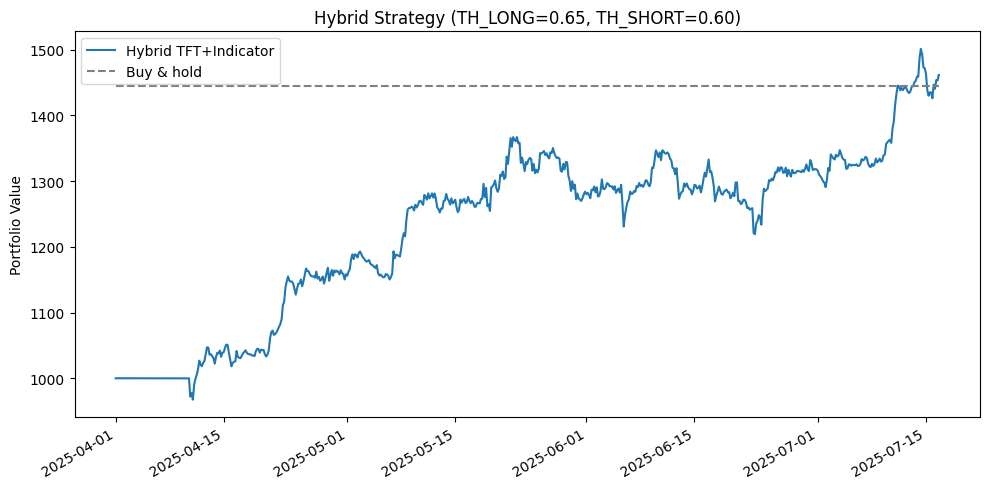

In [ ]:
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────
# 0) ASSUMED EXISTING OBJECTS
# ─────────────────────────────────────────────────────────────────
#   signals      – DataFrame indexed by timestamps, with column 'p_up'
#   price_lookup – Series of Close prices indexed by those same timestamps
#   START_CASH, FEE defined as before
#   h3           – your full hourly DataFrame (contains 'Close','rsi14')
# ─────────────────────────────────────────────────────────────────

# 1) Compute the 200‑hour MA and ensure RSI14 exists
h3["MA200"] = h3["Close"].rolling(200).mean()
if "rsi14" not in h3.columns:
    # Assuming you know how to compute RSI14; otherwise use your previous code
    delta = h3["Close"].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    h3["rsi14"] = 100 - 100 / (1 + gain / loss)

# 2) Build a fresh signals DataFrame that includes TFT prob + RSI + MA
signal_index = signals.index  # already filtered to 4h grid
hybrid = pd.DataFrame(index=signal_index)
hybrid["p_up"]  = signals["p_up"]
hybrid["rsi14"] = h3.loc[signal_index, "rsi14"].values
hybrid["ma200"] = h3.loc[signal_index, "MA200"].values
hybrid["price"] = price_lookup.loc[signal_index].values

# 3) Hybrid back‑test function
def backtest_hybrid(df, th_long, th_short,
                    rsi_long=30, rsi_short=70):
    cash, asset, position = START_CASH, 0.0, 0
    for ts, row in df.iterrows():
        p_up, rsi, ma, price = row[["p_up","rsi14","ma200","price"]]

        # EXIT first
        if position ==  1 and p_up < 0.50:
            cash  = asset * price * (1 - FEE); asset = 0.0; position = 0
        elif position == -1 and p_up > 0.50:
            cash += asset * price * (1 - FEE); asset = 0.0; position = 0

        # ENTRY if flat
        if position == 0:
            # long only if model + oversold + above MA
            if p_up > th_long and rsi < rsi_long and price > ma:
                cash_to_use = cash * (1 - FEE)
                asset       = cash_to_use / price
                cash        = 0.0
                position    = 1
            # short only if model + overbought + below MA
            elif p_up < th_short and rsi > rsi_short and price < ma:
                size    = cash / price
                proceeds= size * price * (1 - FEE)
                cash   += proceeds
                asset   = -size
                position= -1

    # final liquidation
    last_price = df["price"].iloc[-1]
    if position ==  1:
        cash  = asset * last_price * (1 - FEE)
    elif position == -1:
        cash += asset * last_price * (1 - FEE)
    return cash

# 4) Grid‑search p_up thresholds for best equity
th_vals = np.arange(0.60, 0.91, 0.05)
best_eq = -np.inf
best_long = best_short = None

for th_long, th_short in product(th_vals, th_vals):
    if th_short >= th_long: continue
    eq = backtest_hybrid(hybrid, th_long, th_short)
    if eq > best_eq:
        best_eq, best_long, best_short = eq, th_long, th_short

print(f"🏆 Best TFT thresholds: TH_LONG={best_long:.2f}, TH_SHORT={best_short:.2f}; Equity=${best_eq:,.2f}")

# 5) Run once more to get equity curve
eq_curve = []
cash, asset, position = START_CASH, 0.0, 0
for ts, row in hybrid.iterrows():
    p_up, rsi, ma, price = row[["p_up","rsi14","ma200","price"]]
    # exits
    if position ==  1 and p_up < 0.50:
        cash  = asset * price * (1 - FEE); asset = 0.0; position = 0
    elif position == -1 and p_up > 0.50:
        cash += asset * price * (1 - FEE); asset = 0.0; position = 0
    # entries
    if position == 0:
        if p_up > best_long and rsi < 30 and price > ma:
            cash_to_use = cash * (1 - FEE)
            asset       = cash_to_use / price
            cash        = 0.0
            position    = 1
        elif p_up < best_short and rsi > 70 and price < ma:
            size    = cash / price
            proceeds= size * price * (1 - FEE)
            cash   += proceeds
            asset   = -size
            position= -1
    eq_curve.append((ts, cash + asset * price))

# final liquidation
last_price = hybrid["price"].iloc[-1]
if position ==  1:
    cash  = asset * last_price * (1 - FEE)
elif position == -1:
    cash += asset * last_price * (1 - FEE)
eq_curve.append((hybrid.index[-1], cash))

# 6) Plot
eq_series = pd.Series(
    [v for _, v in eq_curve],
    index=[t for t,_ in eq_curve]
).sort_index()

first_ts = hybrid.index[0]
last_ts  = hybrid.index[-1]
buy_hold = START_CASH * price_lookup.at[last_ts] / price_lookup.at[first_ts]
bh_series = pd.Series(buy_hold, index=eq_series.index)

plt.figure(figsize=(10,5))
eq_series.plot(label="Hybrid TFT+Indicator")
bh_series.plot(linestyle="--", color="gray", label="Buy & hold")
plt.title(f"Hybrid Strategy (TH_LONG={best_long:.2f}, TH_SHORT={best_short:.2f})")
plt.ylabel("Portfolio Value")
plt.legend()
plt.tight_layout()
plt.show()


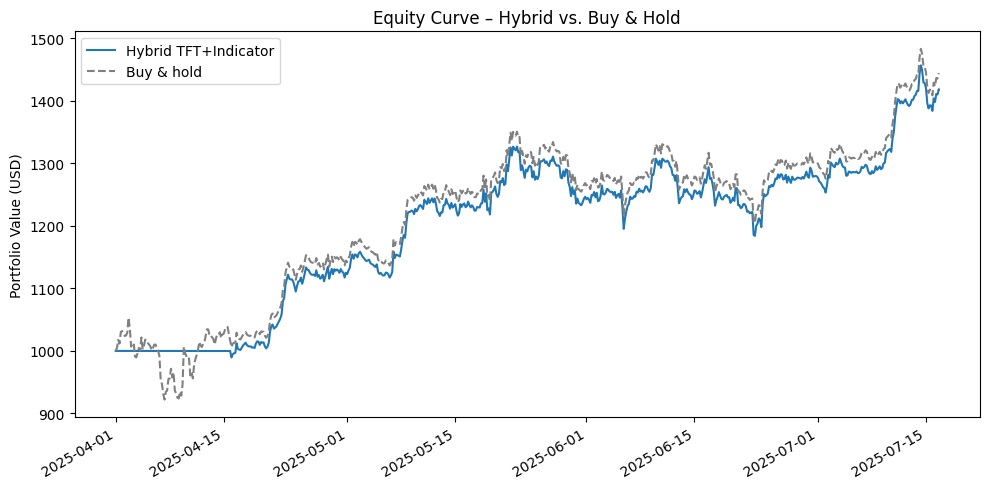

In [ ]:
# eq_s is your final TFT equity series
# price_lookup is your full hourly Close series

# build a buy‑&‑hold curve aligned to eq_s.index
bh_prices = price_lookup.reindex(eq_s.index, method="ffill")
bh_series = START_CASH * (bh_prices / bh_prices.iloc[0])

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
eq_s.plot(label="Hybrid TFT+Indicator")
bh_series.plot(linestyle="--", color="gray", label="Buy & hold")
plt.title("Equity Curve – Hybrid vs. Buy & Hold")
plt.ylabel("Portfolio Value (USD)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# crossx/task4/pepe_eth_leadlag.py
from __future__ import annotations
import argparse, time, math
from typing import List, Tuple
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def make_exchange(name: str):
    ex = getattr(ccxt, name.lower())({"enableRateLimit": True, "timeout": 15000})
    # ensure MAINNET (historical data is not on testnet)
    try:
        ex.set_sandbox_mode(False)
    except Exception:
        pass
    return ex

def fetch_ohlcv(exname: str, symbol: str, timeframe: str, since_iso: str, limit: int = 1000) -> pd.DataFrame:
    ex = make_exchange(exname)
    since = ex.parse8601(since_iso) if since_iso else None
    rows_all: List[List[float]] = []
    last = since
    while True:
        rows = ex.fetch_ohlcv(symbol, timeframe=timeframe, since=last, limit=limit)
        if not rows:
            break
        rows_all.extend(rows)
        last = rows[-1][0] + 1
        if len(rows) < limit:
            break
        time.sleep(ex.rateLimit / 1000.0)
    if not rows_all:
        raise RuntimeError(f"No OHLCV returned for {exname} {symbol}")
    df = pd.DataFrame(rows_all, columns=["ts","open","high","low","close","volume"])
    df["time"] = pd.to_datetime(df["ts"], unit="ms", utc=True)
    df.set_index("time", inplace=True)
    return df[["open","high","low","close","volume"]]

def cross_corr(a: np.ndarray, b: np.ndarray, lags: range) -> Tuple[np.ndarray, np.ndarray]:
    """
    Return correlations for each lag in 'lags'.
    We define lag > 0 as: corr( b_t , a_{t - lag} ) --> 'a' LEADS 'b' by 'lag'.
    """
    out = []
    for k in lags:
        if k > 0:
            x = a[:-k]; y = b[k:]
        elif k < 0:
            x = a[-k:]; y = b[:k]  # k is negative
        else:
            x = a; y = b
        if len(x) < 2:
            out.append(np.nan)
            continue
        vx = x - x.mean(); vy = y - y.mean()
        denom = (vx.std(ddof=1) * vy.std(ddof=1))
        out.append(float((vx @ vy) / ((len(x) - 1) * denom))) if denom > 0 else out.append(np.nan)
    return np.array(list(lags)), np.array(out)

def main():
    ap = argparse.ArgumentParser(description="PEPE vs ETH lead-lag and normalization")
    ap.add_argument("--exchange", default="binance", help="binance|okx|kucoin (all have PEPE/USDT)")
    ap.add_argument("--timeframe", default="1m", help="1m, 5m, 15m, 1h, 1d")
    ap.add_argument("--since", default="", help="ISO8601 start, e.g. 2025-07-20T00:00:00Z")
    ap.add_argument("--lags", default=120, type=int, help="check +/- this many bars (e.g., 120 for +/-120 minutes on 1m)")
    ap.add_argument("--show", action="store_true", help="display charts interactively")
    ap.add_argument("--out-prefix", default="pepe_eth")
    args = ap.parse_args()

    # Symbols per exchange
    ex = args.exchange.lower()
    eth_sym = "ETH/USDT"
    pepe_sym = "PEPE/USDT"
    if ex == "okx":
        eth_sym = "ETH/USDT"
        pepe_sym = "PEPE/USDT"
    elif ex == "kucoin":
        eth_sym = "ETH/USDT"
        pepe_sym = "PEPE/USDT"
    # (Coinbase generally does not list PEPE; stick to binance/okx/kucoin)

    # Fetch
    since_iso = args.since or "2025-07-20T00:00:00Z"
    df_eth  = fetch_ohlcv(ex, eth_sym,  args.timeframe, since_iso)
    df_pepe = fetch_ohlcv(ex, pepe_sym, args.timeframe, since_iso)

    # Align on intersection of timestamps
    df = pd.DataFrame({
        "ETH_close":  df_eth["close"],
        "PEPE_close": df_pepe["close"],
    }).dropna()

    if len(df) < 50:
        raise RuntimeError("Not enough overlapping candles after alignment.")

    # Normalizations
    # 1) Index to 1 at start
    idx_eth  = df["ETH_close"]  / df["ETH_close"].iloc[0]
    idx_pepe = df["PEPE_close"] / df["PEPE_close"].iloc[0]

    # 2) Z-score (for scale-free overlay)
    z_eth  = (np.log(df["ETH_close"]).diff().fillna(0)).rolling(60, min_periods=10).apply(lambda x: (x[-1] - x.mean())/(x.std(ddof=1)+1e-12))
    z_pepe = (np.log(df["PEPE_close"]).diff().fillna(0)).rolling(60, min_periods=10).apply(lambda x: (x[-1] - x.mean())/(x.std(ddof=1)+1e-12))

    # Returns for correlation
    r_eth  = np.log(df["ETH_close"]).diff().dropna().to_numpy()
    r_pepe = np.log(df["PEPE_close"]).diff().dropna().to_numpy()

    # Align returns (same length)
    n = min(len(r_eth), len(r_pepe))
    r_eth, r_pepe = r_eth[-n:], r_pepe[-n:]

    # Cross-correlation over lags
    lag_range = range(-args.lags, args.lags + 1)
    lags, corrs = cross_corr(r_eth, r_pepe, lag_range)
    # Best lag
    best_idx = int(np.nanargmax(np.abs(corrs)))  # max absolute correlation
    best_lag = int(lags[best_idx])
    best_corr = float(corrs[best_idx])

    # OLS beta of PEPE on ETH at the best lag
    if best_lag > 0:
        x = r_eth[:-best_lag]; y = r_pepe[best_lag:]
    elif best_lag < 0:
        x = r_eth[-best_lag:]; y = r_pepe[:best_lag]
    else:
        x = r_eth; y = r_pepe
    # add constant? Not needed for returns; force through zero
    beta = float((x @ y) / (x @ x)) if (x @ x) > 0 else float("nan")

    # Save a quick text summary
    with open(f"{args.out_prefix}_summary.txt", "w", encoding="utf-8") as f:
        f.write(f"Exchange       : {args.exchange}\n")
        f.write(f"Timeframe      : {args.timeframe}\n")
        f.write(f"Range          : {since_iso} .. (latest)\n")
        f.write(f"Samples (bars) : {len(df)}\n")
        f.write(f"Best lag       : {best_lag} bars (positive means ETH leads PEPE)\n")
        f.write(f"Best corr      : {best_corr:.4f}\n")
        f.write(f"Beta (PEPE~ETH at best lag): {beta:.4f}\n")

    # --- Plots ---
    # 1) Indexed prices
    plt.figure()
    idx_eth.plot()
    idx_pepe.plot()
    plt.title("Indexed Close (start=1): ETH vs PEPE")
    plt.xlabel("Time (UTC)"); plt.ylabel("Index")
    plt.legend(["ETH", "PEPE"])
    plt.tight_layout()
    plt.savefig(f"{args.out_prefix}_indexed.png", dpi=140)

    # 2) Rolling z-scores (visual co-move)
    plt.figure()
    z_eth.plot()
    z_pepe.plot()
    plt.title("Rolling z-score of log-return: ETH vs PEPE")
    plt.xlabel("Time (UTC)"); plt.ylabel("z-score (60-bar window)")
    plt.legend(["ETH", "PEPE"])
    plt.tight_layout()
    plt.savefig(f"{args.out_prefix}_zscore.png", dpi=140)

    # 3) Cross-correlation vs lag
    plt.figure()
    plt.plot(lags, corrs)
    plt.axvline(0, linestyle="--")
    plt.axvline(best_lag, linestyle=":")
    plt.title("Cross-correlation of returns (lag: ETH leads > 0)")
    plt.xlabel("Lag (bars)"); plt.ylabel("corr")
    plt.tight_layout()
    plt.savefig(f"{args.out_prefix}_xcorr.png", dpi=140)

    if args.show:
        plt.show()

    print(f"Saved: {args.out_prefix}_indexed.png, {args.out_prefix}_zscore.png, {args.out_prefix}_xcorr.png")
    print(f"Summary -> {args.out_prefix}_summary.txt")
    print(f"Best lag = {best_lag} bars, corr = {best_corr:.4f}, beta = {beta:.4f}")

if __name__ == "__main__":
    main()


ModuleNotFoundError: No module named 'ccxt'

In [ ]:
import quant_engine # This imports your compiled C++ code!
import numpy as np

# 1. Prepare your data from your Pandas dataframe
# Assuming 'h3' has your tick/hourly data and 'out' has your PyTorch predictions
timestamps = h3.index.astype(np.int64) // 10**6 # to milliseconds
bids = h3['Close'].values * 0.9999 # Simulated bid
asks = h3['Close'].values * 1.0001 # Simulated ask
volumes = h3['Volume'].values

# Create C++ Tick objects
ticks = [
    quant_engine.Tick(t, b, a, v, v) 
    for t, b, a, v in zip(timestamps, bids, asks, volumes)
]

# 2. Get your TFT Model predictions (1 for buy, -1 for sell, 0 for hold)
# Ensure this matches the length of your tick data
predictions = np.where(out > 0.6, 1, np.where(out < 0.4, -1, 0)).tolist()

# 3. Run the C++ Engine
print("Initializing C++ Backtest Engine...")
engine = quant_engine.BacktestEngine(initial_cash=1000.0, fee=0.00015)

# This loop runs in C++, instantly bypassing Python's GIL
equity_curve = engine.run_simulation(ticks, predictions)

print(f"Final Equity: ${equity_curve[-1]:.2f}")

In [ ]:
import torch
from pytorch_forecasting import TemporalFusionTransformer

# Load your best checkpoint
tft = TemporalFusionTransformer.load_from_checkpoint("TFT_2.ckpt", map_location="cpu")
tft.eval()

# Create a dummy input tensor that matches your model's expected input shape
# (e.g., batch_size=1, sequence_length=X, num_features=Y)
# You will need to adjust this to match your exact TFT input dictionary
dummy_input = ... 

# Export to ONNX
torch.onnx.export(
    tft, 
    dummy_input, 
    "tft_volatility_model.onnx",
    export_params=True,
    opset_version=14,          # Opset 14 is highly stable for transformers
    do_constant_folding=True,  # Optimizes the graph
    input_names=['input'],     # Define the input node name
    output_names=['output']    # Define the output node name
)
print("Model successfully exported to ONNX format.")

In [ ]:

# ─────────────────────────────────────────────────────────────────
# Performance metrics: Sharpe ratio, max drawdown, win rate
# ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

def compute_metrics(equity_curve, risk_free_rate=0.02):
    """
    Calculate Sharpe ratio, max drawdown, and win rate from equity curve.
    
    Args:
        equity_curve: pd.Series with timestamps as index and portfolio values
        risk_free_rate: annual risk-free rate (default 2%)
    
    Returns:
        Dictionary with Sharpe, max_dd, total_return, win_rate
    """
    if len(equity_curve) < 2:
        return {"error": "Not enough data"}
    
    # Daily/hourly returns
    returns = equity_curve.pct_change().dropna()
    
    # Annualize based on frequency
    freq = pd.infer_freq(equity_curve.index)
    if freq == 'H':
        periods_per_year = 24 * 365
    elif freq == 'D':
        periods_per_year = 252
    else:
        periods_per_year = 252  # default to daily
    
    # Sharpe ratio
    annual_ret = returns.mean() * periods_per_year
    annual_vol = returns.std() * np.sqrt(periods_per_year)
    sharpe = (annual_ret - risk_free_rate) / (annual_vol + 1e-8)
    
    # Max drawdown
    cummax = equity_curve.expanding().max()
    drawdown = (equity_curve - cummax) / cummax
    max_dd = drawdown.min()
    
    # Total return
    total_ret = (equity_curve.iloc[-1] - equity_curve.iloc[0]) / equity_curve.iloc[0]
    
    # Win rate (positive daily returns)
    win_rate = (returns > 0).sum() / len(returns) if len(returns) > 0 else 0
    
    return {
        "sharpe": sharpe,
        "max_drawdown": max_dd,
        "total_return": total_ret,
        "annual_return": annual_ret,
        "annual_vol": annual_vol,
        "win_rate": win_rate,
        "n_periods": len(returns)
    }

# Example: compare your TFT strategy vs buy-hold
# Assuming eq_series and buy_hold_series from previous cells
if 'eq_series' in locals():
    tft_metrics = compute_metrics(eq_series)
    bh_metrics = compute_metrics(buy_hold_series)
    
    print("=" * 60)
    print("TFT STRATEGY METRICS")
    print("=" * 60)
    print(f"Sharpe Ratio:        {tft_metrics['sharpe']:.4f}")
    print(f"Max Drawdown:        {tft_metrics['max_drawdown']:.2%}")
    print(f"Total Return:        {tft_metrics['total_return']:.2%}")
    print(f"Annual Return:       {tft_metrics['annual_return']:.2%}")
    print(f"Annual Volatility:   {tft_metrics['annual_vol']:.2%}")
    print(f"Win Rate:            {tft_metrics['win_rate']:.2%}")
    
    print("\n" + "=" * 60)
    print("BUY & HOLD BENCHMARK")
    print("=" * 60)
    print(f"Sharpe Ratio:        {bh_metrics['sharpe']:.4f}")
    print(f"Max Drawdown:        {bh_metrics['max_drawdown']:.2%}")
    print(f"Total Return:        {bh_metrics['total_return']:.2%}")
    print(f"Annual Return:       {bh_metrics['annual_return']:.2%}")
    print(f"Annual Volatility:   {bh_metrics['annual_vol']:.2%}")
    print(f"Win Rate:            {bh_metrics['win_rate']:.2%}")
    
    print("\n" + "=" * 60)
    print("EDGE (TFT vs B&H)")
    print("=" * 60)
    print(f"Sharpe Edge:         {tft_metrics['sharpe'] - bh_metrics['sharpe']:.4f}")
    print(f"Return Edge:         {(tft_metrics['total_return'] - bh_metrics['total_return']):.2%}")
else:
    print("Run your trading strategy cells first to populate eq_series and buy_hold_series")


In [ ]:

# ─────────────────────────────────────────────────────────────────
# Feature validation & dropout tuning suggestions
# ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

print("=" * 70)
print("FEATURE SCALING VALIDATION")
print("=" * 70)

# Check that exogenous features are properly scaled
exog_cols = ["imbalance", "funding_pct", "inflow"]
for col in exog_cols:
    if col in hourly.columns:
        vals = hourly[col].dropna()
        print(f"\n{col}:")
        print(f"  Min: {vals.min():.6f}, Max: {vals.max():.6f}, Mean: {vals.mean():.6f}")
        print(f"  Std: {vals.std():.6f}")
        if (vals.min() == vals.max()):
            print(f"  ⚠️  WARNING: All zeros or constant—model cannot learn from this!")
        elif vals.std() < 0.001:
            print(f"  ⚠️  WARNING: Very low variance—consider scaling or replacing with real data")

print("\n" + "=" * 70)
print("DROPOUT & REGULARIZATION TUNING")
print("=" * 70)
print("""
Current config:
  dropout=0.10, lstm_layers=2, hidden_size=64

Recommendations based on val_loss trajectory:

1. IF val_loss plateaus / training loss >> val_loss:
   → UNDERFITTING: Increase model capacity
   - Try: hidden_size=128, dropout=0.15, lstm_layers=3
   - This gives the model more capacity to learn patterns

2. IF val_loss diverges from training loss / high val_loss:
   → OVERFITTING: Increase regularization
   - Try: dropout=0.25, hidden_size=32, lstm_layers=1
   - Add L2 weight decay: learning_rate_scale=0.9

3. IF val_loss oscillates wildly:
   → UNSTABLE TRAINING: Reduce learning rate
   - Try: learning_rate=2.5e-4 (instead of 5e-4)
   - Increase batch_size to 256 (instead of 128)

4. IF training stalls early:
   → EARLY STOPPING too aggressive
   - Try: patience=10 (instead of 6)
   - Or disable early stopping temporarily for diagnostics

Sweep Template:
""")

print("""
# Add this to test multiple dropout values
dropout_vals = [0.05, 0.10, 0.15, 0.20, 0.25]
for dropout in dropout_vals:
    tft = TemporalFusionTransformer.from_dataset(
        dataset,
        hidden_size=64, lstm_layers=2, dropout=dropout, ← vary this
        attention_head_size=4, learning_rate=5e-4,
        loss=QuantileLoss(), log_interval=100,
        mask_bias=-float("inf"),
    )
    trainer = Trainer(max_epochs=20, callbacks=[...])
    trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)
    # Log results and pick best dropout
""")
